In [1]:
import os
import numpy as np
import pandas as pd
import tensorflow as tf
import joblib
import matplotlib.pyplot as plt

print("TF:", tf.__version__)
print("GPU:", "available" if tf.config.list_physical_devices('GPU') else "NOT AVAILABLE")

# ==============================
# Paths
# ==============================
DATA_DIR = "database"
EVAL_FILE = "small_cases.csv"   # <- 평가용 CSV로 교체

QUALITY_MODEL_PATH = "best_model_residue.h5"       # frozen quality ANN
POLICY_MODEL_PATH  = "best_policy_net.keras"      # trained policy ANN (input 39)

SCALER_X_PATH = "scaler_x_38.pkl"                 # for [u, mon, qprev] (38)
SCALER_Y_PATH = "scaler_y_1.pkl"                  # for residue scaling (1)

# 학습 때와 동일하게
DELTA_MAX_DEFAULT = 0.02

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)


TF: 2.10.0
GPU: available


In [2]:
# ============================================================
# Column definitions (TRAIN과 동일해야 함)
# ============================================================

CONTROL_COLS_9 = [
    "RP_roller_p1",
    "RP_roller_p2",
    "RP_sep_rpm",
    "RP_sep_fan_damper",
    "RP_sep_BF_damper",
    "mill_BF_damper",
    "mill_sep_rpm",
    "mill_sep_fan_damper",
    "grind_aid",
]
assert len(CONTROL_COLS_9) == 9

MONITOR_COLS_28 = [
    "RP_spac",
    "RP_skew",
    "RP_roller_energy1",
    "RP_roller_energy2",
    "RP_roller_vib",
    "RP_BE_energy1",
    "RP_BE_energy2",
    "RP_sep_BF_pressure",
    "dosing_BE_energy",
    "mill_feed_c",
    "mill_feed_cir",
    "mill_energy",
    "mill_in_temp",
    "mill_out_temp",
    "mill_BE_energy",
    "mill_out_gas_temp",
    "mill_out_mater_temp",
    "mill_BF_pressure",
    "mill_sep_BF_pressure",
    "mill_sep_BF_fan_damper",
    "final_BE_1",
    "final_BE_2",
    "final_mater_temp",
    # feed composition moved to monitoring (4)
    "feed_clinker",
    "feed_gypsum",
    "feed_slag",
    "feed_FA",
    # total feed moved to monitoring (1)
    "feed_total",
]
assert len(MONITOR_COLS_28) == 28

# ---- Quality vs Policy 품질 컬럼 분리
QUALITY_PREV_COL   = "residue"        # quality ANN input
POLICY_CUR_COL     = "residue"        # policy ANN input (current quality)
TARGET_QUALITY_COL = "residue_target" # policy ANN input & training target (real unit)

QUALITY_INPUT_COLS = CONTROL_COLS_9 + MONITOR_COLS_28 + [QUALITY_PREV_COL]
assert len(QUALITY_INPUT_COLS) == 38

# policy_net 입력은 39
POLICY_INPUT_DIM = 28 + 1 + 9 + 1
assert POLICY_INPUT_DIM == 39

print("QUALITY_INPUT_DIM:", len(QUALITY_INPUT_COLS))
print("POLICY_INPUT_DIM :", POLICY_INPUT_DIM)


QUALITY_INPUT_DIM: 38
POLICY_INPUT_DIM : 39


In [3]:
csv_path = os.path.join(DATA_DIR, EVAL_FILE)
df = pd.read_csv(csv_path)

required_cols = list(set(QUALITY_INPUT_COLS + [POLICY_CUR_COL, TARGET_QUALITY_COL]))
missing_cols = [c for c in required_cols if c not in df.columns]
if missing_cols:
    raise ValueError(f"Missing columns in EVAL CSV: {missing_cols}")

df = df.dropna(subset=required_cols).reset_index(drop=True)
print("Loaded eval data:", df.shape, "from", csv_path)

display(df.head())

scaler_x = joblib.load(SCALER_X_PATH)
scaler_y = joblib.load(SCALER_Y_PATH)

quality_model = tf.keras.models.load_model(QUALITY_MODEL_PATH)
quality_model.trainable = False

policy_net = tf.keras.models.load_model(POLICY_MODEL_PATH)
policy_net.trainable = False

print("Loaded:")
print("- scaler_x:", SCALER_X_PATH)
print("- scaler_y:", SCALER_Y_PATH)
print("- quality_model:", QUALITY_MODEL_PATH, "in/out:", quality_model.input_shape, quality_model.output_shape)
print("- policy_net:", POLICY_MODEL_PATH, "out:", policy_net.output_shape)

def build_eval_tensors(df_raw: pd.DataFrame, scaler_x, scaler_y):
    """
    학습 CELL7 로직을 eval에서 그대로 재현:
      Xq_raw  = [u_cur, mon, qprev]  -> scaler_x -> u_cur_norm, mon_norm, qprev_norm
      qcur_norm, yT_norm -> scaler_y
      Xp_full = [mon_norm, qcur_norm, u_cur_norm, yT_norm, qprev_norm]  (N,40)
      Xp_no_prev = Xp_full[:, :39]  (N,39)  -> policy_net input
    """
    u_cur_raw = df_raw[CONTROL_COLS_9].to_numpy(np.float32)          # (N,9)
    mon_raw   = df_raw[MONITOR_COLS_28].to_numpy(np.float32)         # (N,28)
    qprev_raw = df_raw[[QUALITY_PREV_COL]].to_numpy(np.float32)      # (N,1)
    qcur_raw  = df_raw[[POLICY_CUR_COL]].to_numpy(np.float32)        # (N,1)
    yT_raw    = df_raw[[TARGET_QUALITY_COL]].to_numpy(np.float32)    # (N,1)

    # quality raw/norm
    Xq_raw  = np.concatenate([u_cur_raw, mon_raw, qprev_raw], axis=1)         # (N,38)
    Xq_norm = scaler_x.transform(Xq_raw).astype(np.float32)                   # (N,38)

    u_cur_norm = Xq_norm[:, :9]                                              # (N,9)
    mon_norm   = Xq_norm[:, 9:9+28]                                          # (N,28)
    qprev_norm = Xq_norm[:, 9+28:9+28+1]                                     # (N,1)

    # policy scalers
    qcur_norm = scaler_y.transform(qcur_raw).astype(np.float32)              # (N,1)
    yT_norm   = scaler_y.transform(yT_raw).astype(np.float32)                # (N,1)

    # Xp_full (N,40)
    Xp_full = np.concatenate([mon_norm, qcur_norm, u_cur_norm, yT_norm, qprev_norm], axis=1).astype(np.float32)
    assert Xp_full.shape[1] == POLICY_INPUT_DIM + 1   # 40

    # policy input only (N,39)
    Xp_no_prev = Xp_full[:, :39]
    assert Xp_no_prev.shape[1] == POLICY_INPUT_DIM

    return {
        "Xp_full": Xp_full,
        "Xp_no_prev": Xp_no_prev,
        "u_cur_raw": u_cur_raw,
        "qcur_raw": qcur_raw,
        "qprev_raw": qprev_raw,
        "yT_raw": yT_raw,
        "u_cur_norm": u_cur_norm,
        "mon_norm": mon_norm,
        "qprev_norm": qprev_norm,
        "qcur_norm": qcur_norm,
        "yT_norm": yT_norm,
    }


Loaded eval data: (9, 43) from database\small_cases.csv


,RP_roller_p1,RP_roller_p2,RP_sep_rpm,RP_sep_fan_damper,RP_sep_BF_damper,mill_BF_damper,mill_sep_rpm,mill_sep_fan_damper,grind_aid,RP_spac,RP_skew,RP_roller_energy1,RP_roller_energy2,RP_roller_vib,RP_BE_energy1,RP_BE_energy2,RP_sep_BF_pressure,dosing_BE_energy,mill_feed_c,mill_feed_cir,mill_energy,mill_in_temp,mill_out_temp,mill_BE_energy,mill_out_gas_temp,mill_out_mater_temp,mill_BF_pressure,mill_sep_BF_pressure,mill_sep_BF_fan_damper,final_BE_1,final_BE_2,final_mater_temp,feed_total,feed_clinker,feed_gypsum,feed_slag,feed_FA,blaine,residue,blaine_prev,residue_prev,blaine_target,residue_target
0,74,73,463,100,60,25,1112,100,149.4,46,1,147,144,1.0,0,124,-103,22,364,576,163,50,58,68,109,115,-149,-283,30,88,77,95,223.2,189.6,11.3,11.1,11.2,3550,8.9,3720,8.7,3800,8
1,73,77,390,100,60,15,1165,100,151.2,43,0,145,133,1.5,0,124,-84,20,338,546,172,34,43,71,95,101,-132,-236,30,90,78,78,221.1,190.1,11.2,11.0,8.8,3700,7.8,3860,8.5,3800,8
2,68,77,445,100,60,15,1156,100,151.2,49,0,148,141,1.3,0,125,-68,19,389,613,161,46,54,71,99,105,-115,-224,30,90,78,88,217.2,186.7,11.0,10.8,8.7,3780,8.2,3590,8.5,3800,8
3,78,79,462,100,60,15,1146,100,158.4,48,0,159,151,1.1,0,121,-72,20,398,613,168,45,53,74,101,108,-121,-219,30,72,61,89,220.2,186.3,10.7,11.0,12.2,3570,8.6,3680,8.3,3800,8
4,74,76,446,100,60,20,1139,100,199.8,42,7,153,146,1.2,0,124,-86,20,360,571,168,49,56,70,110,116,-128,-268,30,85,77,95,217.9,184.8,11.3,10.9,10.9,3610,8.7,3590,8.6,3800,8


Loaded:
- scaler_x: scaler_x_38.pkl
- scaler_y: scaler_y_1.pkl
- quality_model: best_model_residue.h5 in/out: (None, 38) (None, 1)
- policy_net: best_policy_net.keras out: (None, 9)


In [4]:
def eval_policy(df_raw: pd.DataFrame,
                policy_net,
                quality_model,
                scaler_x,
                scaler_y,
                delta_max_default: float = 0.02) -> pd.DataFrame:
    pack = build_eval_tensors(df_raw, scaler_x, scaler_y)

    Xp_no_prev = pack["Xp_no_prev"]             # (N,39) policy input
    mon_norm   = pack["mon_norm"]               # (N,28)
    u_cur_norm = pack["u_cur_norm"]             # (N,9)
    qprev_norm = pack["qprev_norm"]             # (N,1)

    u_cur_raw  = pack["u_cur_raw"]              # (N,9) raw unit
    qcur_raw   = pack["qcur_raw"].reshape(-1)   # (N,)
    qprev_raw  = pack["qprev_raw"].reshape(-1)  # (N,)
    yT_raw     = pack["yT_raw"].reshape(-1)     # (N,)

    # 1) policy forward (delta_raw in [-1,1])
    delta_raw = policy_net(Xp_no_prev, training=False).numpy().astype(np.float32)   # (N,9)
    DELTA_MAX = np.array([delta_max_default]*9, dtype=np.float32).reshape(1, -1)
    delta_norm = delta_raw * DELTA_MAX                                              # (N,9)

    u_new_norm = np.clip(u_cur_norm + delta_norm, 0.0, 1.0)                         # (N,9)

    # 2) quality forward (38): [u_new, mon, qprev]
    Xq_new_norm = np.concatenate([u_new_norm, mon_norm, qprev_norm], axis=1).astype(np.float32)  # (N,38)
    y_pred_norm = quality_model(Xq_new_norm, training=False).numpy().astype(np.float32)          # (N,1)

    # 3) inverse to real unit (residue)
    y_pred_real = scaler_y.inverse_transform(y_pred_norm).reshape(-1)               # (N,)

    # 4) inverse to raw unit for u_new (controls)
    Xq_new_raw = scaler_x.inverse_transform(Xq_new_norm).astype(np.float32)         # (N,38)
    u_new_raw = Xq_new_raw[:, :9]                                                   # (N,9)
    delta_raw_unit = u_new_raw - u_cur_raw                                          # (N,9)

    # 5) result table
    out = pd.DataFrame({
        "qcur(residue)": qcur_raw,
        "qprev(residue_prev)": qprev_raw,
        "target(residue_target)": yT_raw,
        "pred(residue_pred)": y_pred_real,
        "target-pred": (yT_raw - y_pred_real),
        "pred-qcur": (y_pred_real - qcur_raw),
    })

    for i, c in enumerate(CONTROL_COLS_9):
        out[f"{c}_cur"]   = u_cur_raw[:, i]
        out[f"{c}_new"]   = u_new_raw[:, i]
        out[f"{c}_delta"] = delta_raw_unit[:, i]

    return out


In [5]:
result_df = eval_policy(
    df_raw=df,
    policy_net=policy_net,
    quality_model=quality_model,
    scaler_x=scaler_x,
    scaler_y=scaler_y,
    delta_max_default=DELTA_MAX_DEFAULT
)

display(result_df)


,qcur(residue),qprev(residue_prev),target(residue_target),pred(residue_pred),target-pred,pred-qcur,RP_roller_p1_cur,RP_roller_p1_new,RP_roller_p1_delta,RP_roller_p2_cur,RP_roller_p2_new,RP_roller_p2_delta,RP_sep_rpm_cur,RP_sep_rpm_new,RP_sep_rpm_delta,RP_sep_fan_damper_cur,RP_sep_fan_damper_new,RP_sep_fan_damper_delta,RP_sep_BF_damper_cur,RP_sep_BF_damper_new,RP_sep_BF_damper_delta,mill_BF_damper_cur,mill_BF_damper_new,mill_BF_damper_delta,mill_sep_rpm_cur,mill_sep_rpm_new,mill_sep_rpm_delta,mill_sep_fan_damper_cur,mill_sep_fan_damper_new,mill_sep_fan_damper_delta,grind_aid_cur,grind_aid_new,grind_aid_delta
0,8.9,8.9,8.0,8.456601,-0.456601,-0.443398,74.0,70.180000,-3.820000,73.0,76.600006,3.600006,463.0,454.561005,-8.438995,100.0,99.631989,-0.368011,60.0,58.240002,-1.759998,25.0,23.539997,-1.460003,1112.0,1136.938721,24.938721,100.0,99.599998,-0.400002,149.399994,116.130020,-33.269974
1,7.8,7.8,8.0,8.062366,-0.062366,0.262366,73.0,74.371292,1.371292,77.0,80.599724,3.599724,390.0,398.399719,8.399719,100.0,99.500038,-0.499962,60.0,58.240002,-1.759998,15.0,13.540000,-1.460000,1165.0,1189.936768,24.936768,100.0,99.600006,-0.399994,151.199997,121.924294,-29.275703
2,8.2,8.2,8.0,8.142187,-0.142187,-0.057813,68.0,71.820007,3.820007,77.0,73.400002,-3.599998,445.0,453.439911,8.439911,100.0,99.500000,-0.500000,60.0,58.240002,-1.759998,15.0,13.540000,-1.460000,1156.0,1180.937744,24.937744,100.0,99.600143,-0.399857,151.199997,165.790115,14.590118
3,8.6,8.6,8.0,8.298753,-0.298753,-0.301248,78.0,77.831589,-0.168411,79.0,81.902283,2.902283,462.0,453.559998,-8.440002,100.0,100.000000,0.000000,60.0,58.240002,-1.759998,15.0,13.541832,-1.458168,1146.0,1170.931641,24.931641,100.0,99.599998,-0.400002,158.399994,125.130089,-33.269905
4,8.7,8.7,8.0,8.434825,-0.434825,-0.265175,74.0,77.813812,3.813812,76.0,79.552208,3.552208,446.0,437.560028,-8.439972,100.0,99.500038,-0.499962,60.0,58.240002,-1.759998,20.0,21.459478,1.459478,1139.0,1163.939819,24.939819,100.0,99.599998,-0.400002,199.800003,166.529999,-33.270004
5,8.5,8.5,8.0,8.265089,-0.265089,-0.234911,78.0,74.180000,-3.820000,77.0,80.600006,3.600006,454.0,445.559998,-8.440002,100.0,100.000000,0.000000,60.0,58.240002,-1.759998,20.0,18.539999,-1.460001,1145.0,1169.935669,24.935669,100.0,99.599998,-0.400002,210.600006,177.451599,-33.148407
6,8.7,8.7,8.0,8.375319,-0.375319,-0.324681,81.0,77.180000,-3.820000,83.0,86.600006,3.600006,404.0,412.439972,8.439972,100.0,99.500023,-0.499977,60.0,58.240002,-1.759998,20.0,18.539999,-1.460001,1119.0,1143.939697,24.939697,100.0,99.599998,-0.400002,210.600006,177.330017,-33.269989
7,9.0,9.0,8.0,8.484153,-0.484153,-0.515847,81.0,77.180000,-3.820000,83.0,86.600006,3.600006,472.0,463.559998,-8.440002,100.0,100.000000,0.000000,60.0,58.240002,-1.759998,25.0,23.540003,-1.459997,1102.0,1126.925537,24.925537,100.0,99.599998,-0.400002,149.399994,182.669983,33.269989
8,4.5,4.5,8.0,4.878625,3.121375,0.378625,76.0,72.180000,-3.820000,85.0,88.600006,3.600006,467.0,475.439972,8.439972,100.0,100.000000,0.000000,40.0,41.760002,1.760002,30.0,28.539995,-1.460005,1037.0,1012.060059,-24.939941,100.0,100.000000,0.000000,156.100006,189.370010,33.270004


In [ ]:
summary_cols = [
    "qcur(residue)", "qprev(residue_prev)", "target(residue_target)",
    "pred(residue_pred)", "target-pred", "pred-qcur"
]
delta_cols = [f"{c}_delta" for c in CONTROL_COLS_9]

print("===== Summary =====")
display(result_df[summary_cols])

print("===== Control deltas (raw unit) =====")
display(result_df[delta_cols])

===== Summary =====


,qcur(residue),qprev(residue_prev),target(residue_target),pred(residue_pred),target-pred,pred-qcur
0,8.9,8.9,8.0,8.456601,-0.456601,-0.443398
1,7.8,7.8,8.0,8.062366,-0.062366,0.262366
2,8.2,8.2,8.0,8.142187,-0.142187,-0.057813
3,8.6,8.6,8.0,8.298753,-0.298753,-0.301248
4,8.7,8.7,8.0,8.434825,-0.434825,-0.265175
5,8.5,8.5,8.0,8.265089,-0.265089,-0.234911
6,8.7,8.7,8.0,8.375319,-0.375319,-0.324681
7,9.0,9.0,8.0,8.484153,-0.484153,-0.515847
8,4.5,4.5,8.0,4.878625,3.121375,0.378625


===== Control deltas (raw unit) =====


,RP_roller_p1_delta,RP_roller_p2_delta,RP_sep_rpm_delta,RP_sep_fan_damper_delta,RP_sep_BF_damper_delta,mill_BF_damper_delta,mill_sep_rpm_delta,mill_sep_fan_damper_delta,grind_aid_delta
0,-3.820000,3.600006,-8.438995,-0.368011,-1.759998,-1.460003,24.938721,-0.400002,-33.269974
1,1.371292,3.599724,8.399719,-0.499962,-1.759998,-1.460000,24.936768,-0.399994,-29.275703
2,3.820007,-3.599998,8.439911,-0.500000,-1.759998,-1.460000,24.937744,-0.399857,14.590118
3,-0.168411,2.902283,-8.440002,0.000000,-1.759998,-1.458168,24.931641,-0.400002,-33.269905
4,3.813812,3.552208,-8.439972,-0.499962,-1.759998,1.459478,24.939819,-0.400002,-33.270004
5,-3.820000,3.600006,-8.440002,0.000000,-1.759998,-1.460001,24.935669,-0.400002,-33.148407
6,-3.820000,3.600006,8.439972,-0.499977,-1.759998,-1.460001,24.939697,-0.400002,-33.269989
7,-3.820000,3.600006,-8.440002,0.000000,-1.759998,-1.459997,24.925537,-0.400002,33.269989
8,-3.820000,3.600006,8.439972,0.000000,1.760002,-1.460005,-24.939941,0.000000,33.270004


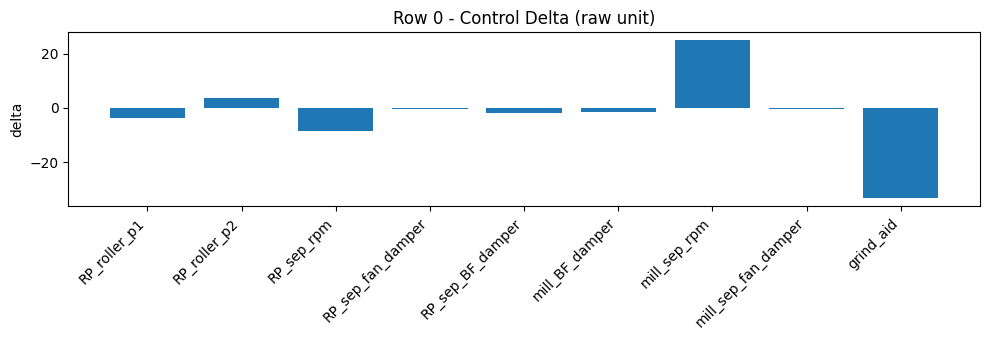

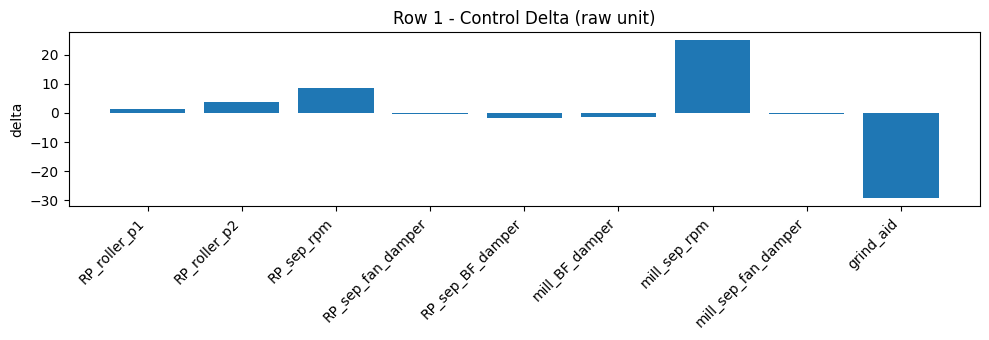

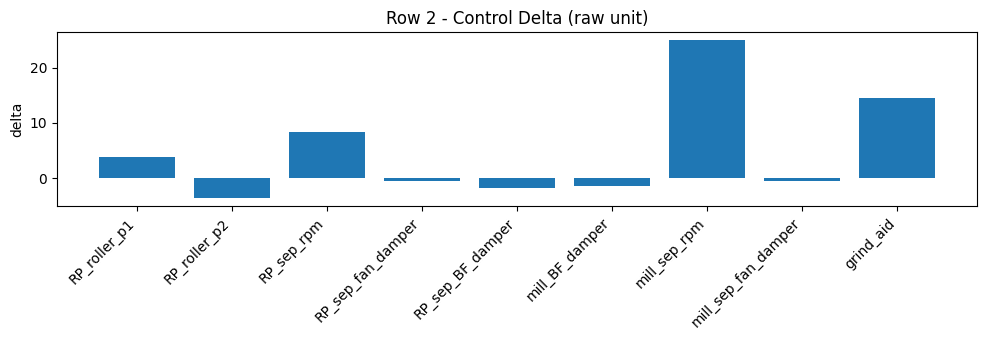

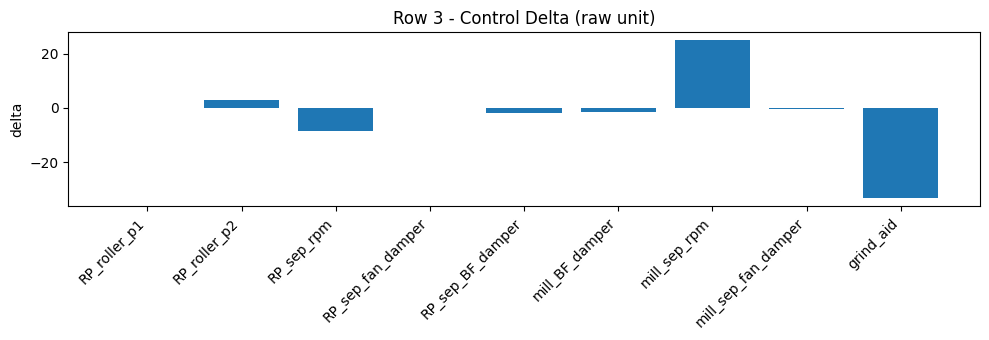

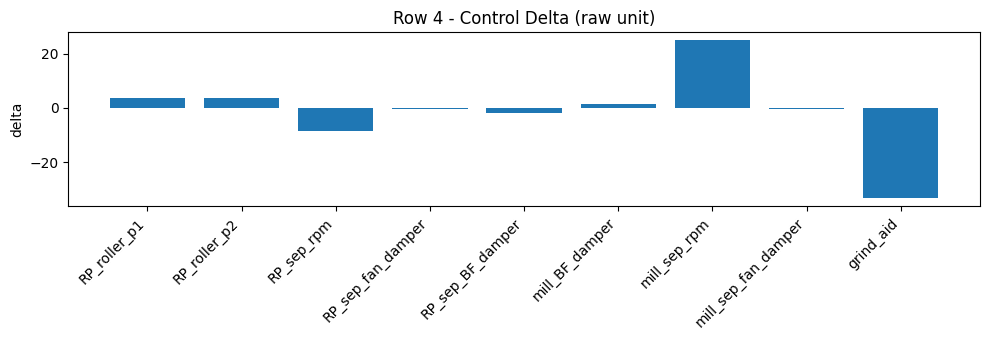

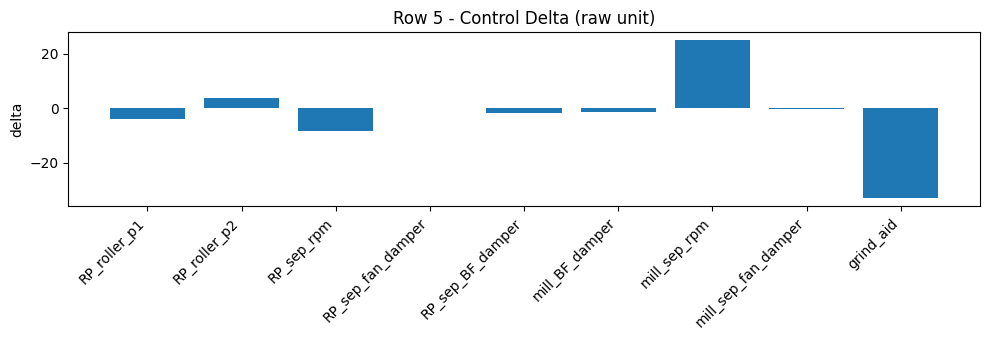

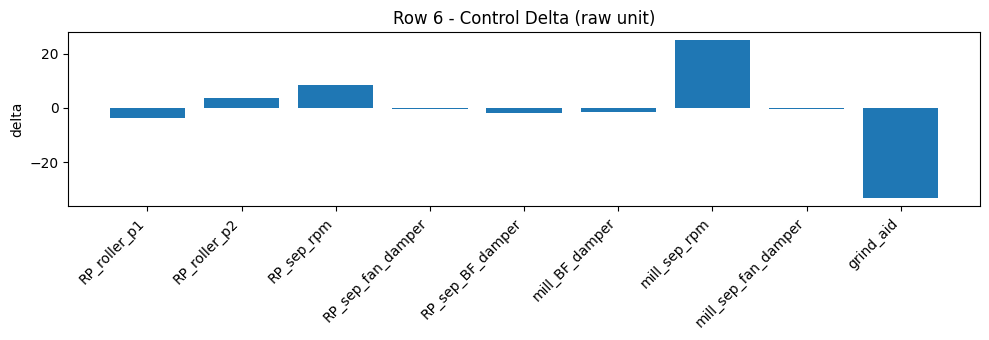

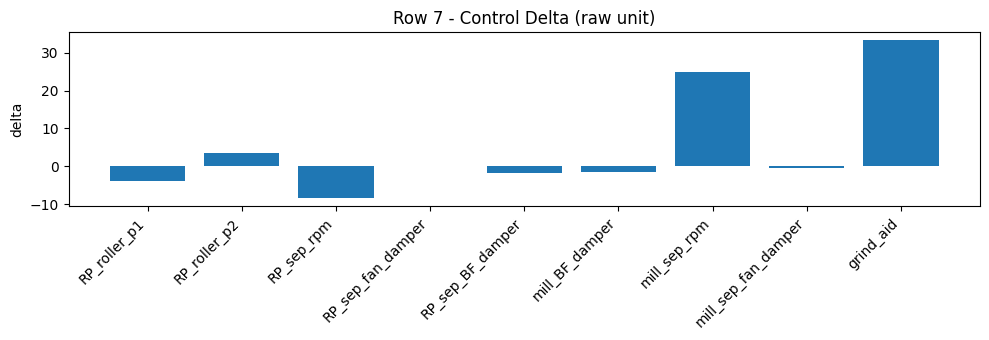

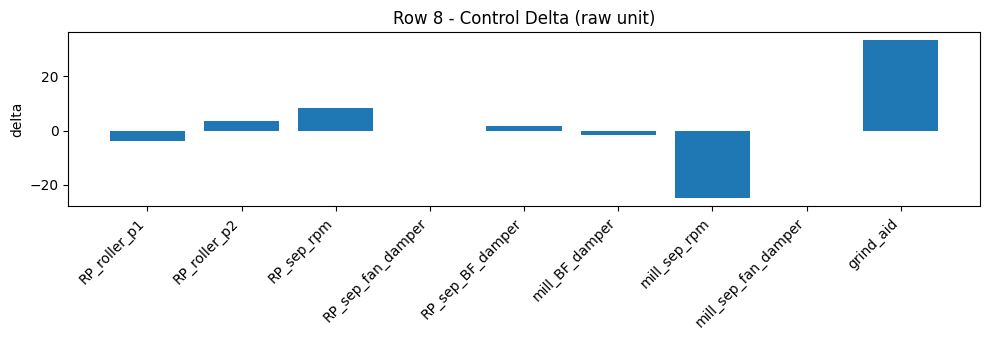

In [7]:
for row_idx in range(len(result_df)):
    deltas = result_df.loc[row_idx, [f"{c}_delta" for c in CONTROL_COLS_9]].to_numpy(np.float32)

    plt.figure(figsize=(10, 3.5))
    plt.bar(np.arange(len(CONTROL_COLS_9)), deltas)
    plt.xticks(np.arange(len(CONTROL_COLS_9)), CONTROL_COLS_9, rotation=45, ha="right")
    plt.title(f"Row {row_idx} - Control Delta (raw unit)")
    plt.ylabel("delta")
    plt.tight_layout()
    plt.show()


In [8]:
OUT_PATH = "eval_policy_result.csv"
result_df.to_csv(OUT_PATH, index=False, encoding="utf-8-sig")
print("Saved:", OUT_PATH)


Saved: eval_policy_result.csv


In [9]:
def make_policy_input_39(u_cur_raw, mon_raw, qcur_raw, yT_raw, scaler_x, scaler_y):
    """
    policy input = [mon_norm(28), qcur_norm(1), u_cur_norm(9), yT_norm(1)]  => (1,39)
    주의: u_cur_norm/mon_norm은 scaler_x로 만든 Xq_norm에서 가져오므로
         qprev_raw도 같이 넣어 Xq_raw(38)을 구성한 뒤 분해합니다.
    """
    # 임시로 qprev를 넣어서 scaler_x 변환 공간을 맞춤(학습 때와 동일한 scaler_x)
    # 여기서 qprev는 policy 입력에는 안 들어가지만, u_cur_norm/mon_norm 만들려면 scaler_x가 필요
    # 따라서 외부에서 qprev_raw를 별도로 넣는 버전이 더 깔끔하지만, 편의를 위해 인자로 받지 않고 0을 둘 수는 없습니다.
    raise NotImplementedError


def quality_predict_from_norm(u_new_norm, mon_norm, qprev_norm, quality_model):
    Xq_new_norm = np.concatenate([u_new_norm, mon_norm, qprev_norm], axis=1).astype(np.float32)  # (1,38)
    y_pred_norm = quality_model(Xq_new_norm, training=False).numpy().astype(np.float32)          # (1,1)
    return y_pred_norm


In [10]:
# ============================================================
# 6) 폐루프 시뮬레이션 함수
# ============================================================

def build_norm_components_from_raw(u_cur_raw, mon_raw, qprev_raw, scaler_x):
    """
    scaler_x는 [u, mon, qprev] 38차원으로 fit되어 있으므로,
    u_cur_norm, mon_norm, qprev_norm을 얻기 위해 동일하게 구성해 변환합니다.
    """
    Xq_raw = np.concatenate([u_cur_raw, mon_raw, qprev_raw], axis=1).astype(np.float32)  # (1,38)
    Xq_norm = scaler_x.transform(Xq_raw).astype(np.float32)                                # (1,38)

    u_cur_norm = Xq_norm[:, :9]
    mon_norm   = Xq_norm[:, 9:9+28]
    qprev_norm = Xq_norm[:, 9+28:9+28+1]
    return u_cur_norm, mon_norm, qprev_norm


def simulate_closed_loop(case_row: pd.Series,
                         policy_net, quality_model,
                         scaler_x, scaler_y,
                         n_steps: int = 30,
                         delta_max_default: float = 0.02):
    """
    상태(state):
      u_cur_raw  : (1,9)   현재 제어 (raw unit)
      mon_raw    : (1,28)  모니터 (raw unit)  -- 시뮬레이션에서는 고정(가정)
      qcur_raw   : (1,1)   현재 품질 (raw unit)
      qprev_raw  : (1,1)   이전 품질 (raw unit)
      yT_raw     : (1,1)   목표 품질 (raw unit) -- 고정(가정)

    loop:
      1) norm components: u_cur_norm, mon_norm, qprev_norm
      2) policy input 39: [mon_norm, qcur_norm, u_cur_norm, yT_norm]
      3) policy -> delta_norm -> u_new_norm -> clip
      4) quality input 38: [u_new_norm, mon_norm, qprev_norm] -> y_next_norm
      5) y_next_raw = inverse(scaler_y)
      6) update: qprev <- qcur, qcur <- y_next, u_cur <- u_new(raw)
    """
    # ----- initial raw
    u_cur_raw = case_row[CONTROL_COLS_9].to_numpy(np.float32).reshape(1, -1)          # (1,9)
    mon_raw   = case_row[MONITOR_COLS_28].to_numpy(np.float32).reshape(1, -1)         # (1,28)
    qprev_raw = np.array([[case_row[QUALITY_PREV_COL]]], dtype=np.float32)            # (1,1)
    qcur_raw  = np.array([[case_row[POLICY_CUR_COL]]], dtype=np.float32)              # (1,1)
    yT_raw    = np.array([[case_row[TARGET_QUALITY_COL]]], dtype=np.float32)          # (1,1)

    # delta bound
    DELTA_MAX = np.array([delta_max_default]*9, dtype=np.float32).reshape(1, -1)

    logs = []

    for k in range(n_steps):
        # (A) build norm components for current state
        u_cur_norm, mon_norm, qprev_norm = build_norm_components_from_raw(u_cur_raw, mon_raw, qprev_raw, scaler_x)

        # (B) policy input 39
        qcur_norm = scaler_y.transform(qcur_raw).astype(np.float32)   # (1,1)
        yT_norm   = scaler_y.transform(yT_raw).astype(np.float32)     # (1,1)

        Xp_39 = np.concatenate([mon_norm, qcur_norm, u_cur_norm, yT_norm], axis=1).astype(np.float32)
        assert Xp_39.shape[1] == 39

        # (C) policy forward
        delta_raw = policy_net(Xp_39, training=False).numpy().astype(np.float32)     # (1,9) in [-1,1]
        delta_norm = delta_raw * DELTA_MAX                                           # (1,9)
        u_new_norm = np.clip(u_cur_norm + delta_norm, 0.0, 1.0)                      # (1,9)

        # (D) quality forward (uses qprev_norm)
        Xq_new_norm = np.concatenate([u_new_norm, mon_norm, qprev_norm], axis=1).astype(np.float32)  # (1,38)
        y_next_norm = quality_model(Xq_new_norm, training=False).numpy().astype(np.float32)          # (1,1)

        # (E) convert to raw
        y_next_raw = scaler_y.inverse_transform(y_next_norm).astype(np.float32)      # (1,1)

        # u_new_raw 복원 (controls only)
        Xq_new_raw = scaler_x.inverse_transform(Xq_new_norm).astype(np.float32)      # (1,38)
        u_new_raw  = Xq_new_raw[:, :9]                                               # (1,9)

        # log
        logs.append({
            "step": k,
            "qprev": float(qprev_raw[0,0]),
            "qcur":  float(qcur_raw[0,0]),
            "target": float(yT_raw[0,0]),
            "pred_next": float(y_next_raw[0,0]),
            "err(target-pred_next)": float(yT_raw[0,0] - y_next_raw[0,0]),
            **{f"{c}_cur": float(u_cur_raw[0,i]) for i,c in enumerate(CONTROL_COLS_9)},
            **{f"{c}_new": float(u_new_raw[0,i]) for i,c in enumerate(CONTROL_COLS_9)},
            **{f"{c}_delta": float(u_new_raw[0,i] - u_cur_raw[0,i]) for i,c in enumerate(CONTROL_COLS_9)},
        })

        # (F) update state
        qprev_raw = qcur_raw.copy()
        qcur_raw  = y_next_raw.copy()
        u_cur_raw = u_new_raw.copy()

    return pd.DataFrame(logs)


In [25]:
# ============================================================
# 7) 시뮬레이션 작동
# ============================================================

ROW_IDX = 0   # 사용자가 1번째 row를 선택 -> 0 (0-based)
N_STEPS = 30
case_row = df.iloc[ROW_IDX]

sim_df = simulate_closed_loop(
    case_row=case_row,
    policy_net=policy_net,
    quality_model=quality_model,
    scaler_x=scaler_x,
    scaler_y=scaler_y,
    n_steps=N_STEPS,
    delta_max_default=DELTA_MAX_DEFAULT
)

display(sim_df)

,step,qprev,qcur,target,pred_next,err(target-pred_next),RP_roller_p1_cur,RP_roller_p2_cur,RP_sep_rpm_cur,RP_sep_fan_damper_cur,RP_sep_BF_damper_cur,mill_BF_damper_cur,mill_sep_rpm_cur,mill_sep_fan_damper_cur,grind_aid_cur,RP_roller_p1_new,RP_roller_p2_new,RP_sep_rpm_new,RP_sep_fan_damper_new,RP_sep_BF_damper_new,mill_BF_damper_new,mill_sep_rpm_new,mill_sep_fan_damper_new,grind_aid_new,RP_roller_p1_delta,RP_roller_p2_delta,RP_sep_rpm_delta,RP_sep_fan_damper_delta,RP_sep_BF_damper_delta,mill_BF_damper_delta,mill_sep_rpm_delta,mill_sep_fan_damper_delta,grind_aid_delta
0,0,8.900000,8.900000,8.0,8.456601,-0.456601,74.000000,73.000000,463.000000,100.000000,60.000000,25.000000,1112.000000,100.000000,149.399994,70.180000,76.600006,454.561005,99.631966,58.240002,23.539997,1136.938721,99.599998,116.130020,-3.820000,3.600006,-8.438995,-0.368034,-1.759998,-1.460003,24.938721,-0.400002,-33.269974
1,1,8.900000,8.456601,8.0,8.180272,-0.180272,70.180000,76.600006,454.561005,99.631966,58.240002,23.539997,1136.938721,99.599998,116.130020,66.360001,80.200005,461.643127,99.135612,56.480003,22.079994,1161.878540,99.199997,82.869392,-3.820000,3.599998,7.082123,-0.496353,-1.759998,-1.460003,24.939819,-0.400002,-33.260628
2,2,8.456601,8.180272,8.0,8.044821,-0.044821,66.360001,80.200005,461.643127,99.135612,56.480003,22.079994,1161.878540,99.199997,82.869392,62.540401,83.800011,470.078339,98.635674,54.720005,20.619991,1186.817017,98.800270,116.139000,-3.819599,3.600006,8.435211,-0.499939,-1.759998,-1.460003,24.938477,-0.399727,33.269608
3,3,8.180272,8.044821,8.0,7.901532,0.098468,62.540401,83.800011,470.078339,98.635674,54.720005,20.619991,1186.817017,98.800270,116.139000,61.248089,87.399956,478.435425,98.135696,52.960007,19.159992,1211.751465,98.400734,149.408951,-1.292313,3.599945,8.357086,-0.499977,-1.759998,-1.459999,24.934448,-0.399536,33.269951
4,4,8.044821,7.901532,8.0,7.629562,0.370438,61.248089,87.399956,478.435425,98.135696,52.960007,19.159992,1211.751465,98.400734,149.408951,63.847233,90.999611,470.089142,97.636719,51.200008,17.700375,1236.674683,98.001534,182.678772,2.599144,3.599655,-8.346283,-0.498978,-1.759998,-1.459618,24.923218,-0.399200,33.269821
5,5,7.901532,7.629562,8.0,7.447859,0.552141,63.847233,90.999611,470.089142,97.636719,51.200008,17.700375,1236.674683,98.001534,182.678772,66.499054,94.580650,461.649170,97.292320,49.440010,16.419390,1261.507324,97.602509,215.947784,2.651821,3.581039,-8.439972,-0.344398,-1.759998,-1.280985,24.832642,-0.399025,33.269012
6,6,7.629562,7.447859,8.0,7.249343,0.750657,66.499054,94.580650,461.649170,97.292320,49.440010,16.419390,1261.507324,97.602509,215.947784,69.474899,91.379448,453.209167,97.731110,47.680012,17.852570,1284.695679,97.205711,249.165054,2.975845,-3.201202,-8.440002,0.438789,-1.759998,1.433180,23.188354,-0.396797,33.217270
7,7,7.447859,7.249343,8.0,7.174339,0.825661,69.474899,91.379448,453.209167,97.731110,47.680012,17.852570,1284.695679,97.205711,249.165054,72.905273,87.780792,444.769165,98.229729,45.920013,19.311661,1283.422119,96.849640,275.688965,3.430374,-3.598656,-8.440002,0.498619,-1.759998,1.459091,-1.273560,-0.356071,26.523911
8,8,7.249343,7.174339,8.0,7.267442,0.732558,72.905273,87.780792,444.769165,98.229729,45.920013,19.311661,1283.422119,96.849640,275.688965,76.525650,84.181259,436.329193,98.726372,44.160034,20.765337,1278.455078,96.500793,242.903931,3.620377,-3.599533,-8.439972,0.496643,-1.759979,1.453676,-4.967041,-0.348846,-32.785034
9,9,7.174339,7.267442,8.0,7.334276,0.665724,76.525650,84.181259,436.329193,98.726372,44.160034,20.765337,1278.455078,96.500793,242.903931,80.321678,80.582390,427.889191,99.223984,42.400188,22.211946,1279.574463,96.144028,209.634567,3.796028,-3.598869,-8.440002,0.497612,-1.759846,1.446609,1.119385,-0.356766,-33.269363


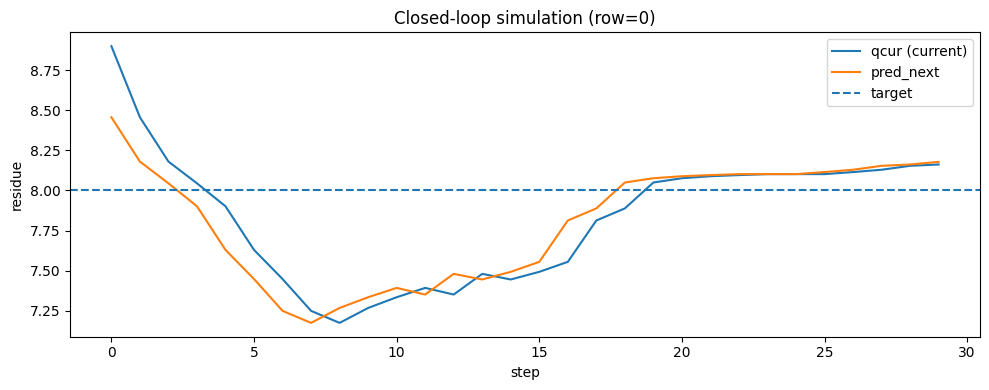

In [26]:
# ============================================================
# 8) 품질 수렴 그래프
# ============================================================

plt.figure(figsize=(10,4))
plt.plot(sim_df["step"], sim_df["qcur"], label="qcur (current)")
plt.plot(sim_df["step"], sim_df["pred_next"], label="pred_next")
plt.axhline(sim_df["target"].iloc[0], linestyle="--", label="target")
plt.xlabel("step")
plt.ylabel("residue")
plt.title(f"Closed-loop simulation (row={ROW_IDX})")
plt.legend()
plt.tight_layout()
plt.show()


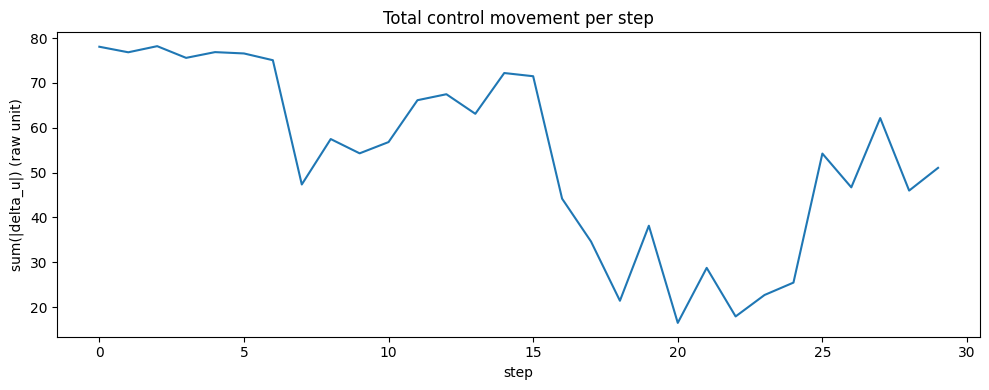

,step,qcur,pred_next,err(target-pred_next),RP_roller_p1_delta,RP_roller_p2_delta,RP_sep_rpm_delta,RP_sep_fan_damper_delta,RP_sep_BF_damper_delta,mill_BF_damper_delta,mill_sep_rpm_delta,mill_sep_fan_damper_delta,grind_aid_delta
0,0,8.900000,8.456601,-0.456601,-3.820000,3.600006,-8.438995,-0.368034,-1.759998,-1.460003,24.938721,-0.400002,-33.269974
1,1,8.456601,8.180272,-0.180272,-3.820000,3.599998,7.082123,-0.496353,-1.759998,-1.460003,24.939819,-0.400002,-33.260628
2,2,8.180272,8.044821,-0.044821,-3.819599,3.600006,8.435211,-0.499939,-1.759998,-1.460003,24.938477,-0.399727,33.269608
3,3,8.044821,7.901532,0.098468,-1.292313,3.599945,8.357086,-0.499977,-1.759998,-1.459999,24.934448,-0.399536,33.269951
4,4,7.901532,7.629562,0.370438,2.599144,3.599655,-8.346283,-0.498978,-1.759998,-1.459618,24.923218,-0.399200,33.269821
5,5,7.629562,7.447859,0.552141,2.651821,3.581039,-8.439972,-0.344398,-1.759998,-1.280985,24.832642,-0.399025,33.269012
6,6,7.447859,7.249343,0.750657,2.975845,-3.201202,-8.440002,0.438789,-1.759998,1.433180,23.188354,-0.396797,33.217270
7,7,7.249343,7.174339,0.825661,3.430374,-3.598656,-8.440002,0.498619,-1.759998,1.459091,-1.273560,-0.356071,26.523911
8,8,7.174339,7.267442,0.732558,3.620377,-3.599533,-8.439972,0.496643,-1.759979,1.453676,-4.967041,-0.348846,-32.785034
9,9,7.267442,7.334276,0.665724,3.796028,-3.598869,-8.440002,0.497612,-1.759846,1.446609,1.119385,-0.356766,-33.269363


In [27]:
# ============================================================
# 9) 각 제어변수 변화량 누적 확인
# ============================================================

delta_cols = [f"{c}_delta" for c in CONTROL_COLS_9]

plt.figure(figsize=(10,4))
plt.plot(sim_df["step"], np.abs(sim_df[delta_cols]).sum(axis=1))
plt.xlabel("step")
plt.ylabel("sum(|delta_u|) (raw unit)")
plt.title("Total control movement per step")
plt.tight_layout()
plt.show()

display(sim_df[["step", "qcur", "pred_next", "err(target-pred_next)"] + delta_cols].head(10))
